# 02 — Feature Engineering

Builds the matchup dataset with rolling performance features used for prediction.

**Features created:**
- Rolling 5-game and 10-game averages for all key stats (no data leakage — only past games used)
- Opponent points allowed (defensive proxy)
- Rest days between games
- Win streak going into each game
- Differential features (home minus away) — the actual model inputs

**Input:** `data/cleaned/team_logs_all_seasons.csv`  
**Output:** `data/cleaned/matchups_features.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/cleaned/team_logs_all_seasons.csv', parse_dates=['GAME_DATE'])
print('Loaded:', df.shape)
df.head()

Loaded: (7380, 19)


,SEASON_ID,GAME_ID,GAME_DATE,TEAM_ABBREVIATION,TEAM_NAME,OPPONENT,HOME_AWAY,WL,WIN,PTS,REB,AST,STL,BLK,TOV,FG_PCT,FG3_PCT,FT_PCT,PLUS_MINUS
0,22022,22200005,2022-10-19,ATL,Atlanta Hawks,HOU,Home,W,1,117,38,30,12,5,9,0.500,0.280,0.833,10
1,22022,22200020,2022-10-21,ATL,Atlanta Hawks,ORL,Home,W,1,108,46,26,10,2,17,0.449,0.419,0.938,10
2,22022,22200038,2022-10-23,ATL,Atlanta Hawks,CHA,Home,L,0,109,45,23,8,9,12,0.411,0.229,0.821,-17
3,22022,22200057,2022-10-26,ATL,Atlanta Hawks,DET,Away,W,1,118,46,22,6,12,12,0.495,0.364,0.800,5
4,22022,22200070,2022-10-28,ATL,Atlanta Hawks,DET,Away,W,1,136,45,31,5,8,7,0.567,0.414,0.778,24


In [3]:
# Rolling averages — grouped by team + season so windows reset each season
# .shift(1) means game N only uses games 1 to N-1 (no leakage)
ROLL_COLS = ['PTS','REB','AST','STL','BLK','TOV','FG_PCT','FG3_PCT','FT_PCT','PLUS_MINUS']

def add_rolling(group, window):
    rolled = group.sort_values('GAME_DATE')[ROLL_COLS].shift(1).rolling(window, min_periods=1).mean()
    rolled.columns = [f'{c}_ROLL{window}' for c in rolled.columns]
    return rolled

df_sorted = df.sort_values(['TEAM_ABBREVIATION','SEASON_ID','GAME_DATE']).reset_index(drop=True)
for w in [5, 10]:
    rolled = df_sorted.groupby(['TEAM_ABBREVIATION','SEASON_ID'], group_keys=False).apply(add_rolling, window=w)
    rolled.index = df_sorted.index
    df_sorted = pd.concat([df_sorted, rolled], axis=1)

print('Shape after rolling features:', df_sorted.shape)

Shape after rolling features: (7380, 39)


/var/folders/4b/ngp188p14txddjbyshqxb9qr0000gn/T/ipykernel_30179/3814948486.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rolled = df_sorted.groupby(['TEAM_ABBREVIATION','SEASON_ID'], group_keys=False).apply(add_rolling, window=w)
/var/folders/4b/ngp188p14txddjbyshqxb9qr0000gn/T/ipykernel_30179/3814948486.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rolled = df_sorted.groupby(['TEAM_ABBREVIAT

In [5]:
# Opponent points allowed (defensive proxy)
pts_lookup = df_sorted.set_index(['GAME_ID','TEAM_ABBREVIATION'])['PTS']
def get_opp_pts(row):
    try: return pts_lookup.loc[(row['GAME_ID'], row['OPPONENT'])]
    except: return np.nan

df_sorted['OPP_PTS'] = df_sorted.apply(get_opp_pts, axis=1)
for w in [5, 10]:
    rd = df_sorted.groupby(['TEAM_ABBREVIATION','SEASON_ID'], group_keys=False)\
        .apply(lambda g: g.sort_values('GAME_DATE')['OPP_PTS'].shift(1).rolling(w, min_periods=1).mean())
    rd.index = df_sorted.index
    df_sorted[f'OPP_PTS_ROLL{w}'] = rd
print('Opponent points allowed added.')

Opponent points allowed added.


/var/folders/4b/ngp188p14txddjbyshqxb9qr0000gn/T/ipykernel_30179/3509018193.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values('GAME_DATE')['OPP_PTS'].shift(1).rolling(w, min_periods=1).mean())
/var/folders/4b/ngp188p14txddjbyshqxb9qr0000gn/T/ipykernel_30179/3509018193.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values('GAME_DATE')['OPP_PTS']

In [7]:
# Rest days and win streak
def add_rest_days(group):
    return group.sort_values('GAME_DATE')['GAME_DATE'].diff().dt.days.fillna(7).clip(upper=7)

def add_win_streak(group):
    g = group.sort_values('GAME_DATE')
    streaks, streak = [], 0
    for win in g['WIN']:
        streaks.append(streak)
        streak = max(streak,0)+1 if win==1 else min(streak,0)-1
    return pd.Series(streaks, index=g.index)

rest = df_sorted.groupby(['TEAM_ABBREVIATION','SEASON_ID'], group_keys=False).apply(add_rest_days)
rest.index = df_sorted.index
df_sorted['REST_DAYS'] = rest

streak = df_sorted.groupby(['TEAM_ABBREVIATION','SEASON_ID'], group_keys=False).apply(add_win_streak)
streak.index = df_sorted.index
df_sorted['WIN_STREAK'] = streak

print('Rest days:', df_sorted['REST_DAYS'].min(), 'to', df_sorted['REST_DAYS'].max())
print('Win streak:', df_sorted['WIN_STREAK'].min(), 'to', df_sorted['WIN_STREAK'].max())

Rest days: 1.0 to 7.0
Win streak: -28 to 16


/var/folders/4b/ngp188p14txddjbyshqxb9qr0000gn/T/ipykernel_30179/991953355.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rest = df_sorted.groupby(['TEAM_ABBREVIATION','SEASON_ID'], group_keys=False).apply(add_rest_days)
/var/folders/4b/ngp188p14txddjbyshqxb9qr0000gn/T/ipykernel_30179/991953355.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  streak = df_sorted.groupby(['TEAM_ABBREVIATION','SEASON

In [13]:
# Build one row per matchup (home vs away)
FEATURE_COLS = [f'{c}_ROLL5' for c in ROLL_COLS] + [f'{c}_ROLL10' for c in ROLL_COLS] + \
               ['OPP_PTS_ROLL5','OPP_PTS_ROLL10','REST_DAYS','WIN_STREAK']

home = df_sorted[df_sorted['HOME_AWAY']=='Home'].copy().rename(columns={c:f'HOME_{c}' for c in FEATURE_COLS})
away = df_sorted[df_sorted['HOME_AWAY']=='Away'].copy().rename(columns={c:f'AWAY_{c}' for c in FEATURE_COLS})

matchups = home[['GAME_ID','GAME_DATE','TEAM_ABBREVIATION','WIN','SEASON_ID']+[f'HOME_{c}' for c in FEATURE_COLS]]\
    .merge(away[['GAME_ID','TEAM_ABBREVIATION']+[f'AWAY_{c}' for c in FEATURE_COLS]], on='GAME_ID')
matchups = matchups.rename(columns={'TEAM_ABBREVIATION_x':'HOME_TEAM','TEAM_ABBREVIATION_y':'AWAY_TEAM','WIN':'home_win'})

for w in [5,10]:
    for c in ROLL_COLS+['OPP_PTS']:
        col=f'{c}_ROLL{w}'
        matchups[f'DIFF_{col}'] = matchups[f'HOME_{col}'] - matchups[f'AWAY_{col}']
matchups['DIFF_REST_DAYS']  = matchups['HOME_REST_DAYS']  - matchups['AWAY_REST_DAYS']
matchups['DIFF_WIN_STREAK'] = matchups['HOME_WIN_STREAK'] - matchups['AWAY_WIN_STREAK']

before = len(matchups)
matchups = matchups.dropna().reset_index(drop=True)
print(f'Matchups: {before} -> {len(matchups)} after dropping early-season NaN rows')
print(f'Home win rate: {matchups["home_win"].mean():.1%}')
matchups.to_csv('../data/cleaned/matchups_features.csv', index=False)
print('Saved: data/cleaned/matchups_features.csv')

Matchups: 3685 -> 3638 after dropping early-season NaN rows
Home win rate: 55.7%
Saved: data/cleaned/matchups_features.csv


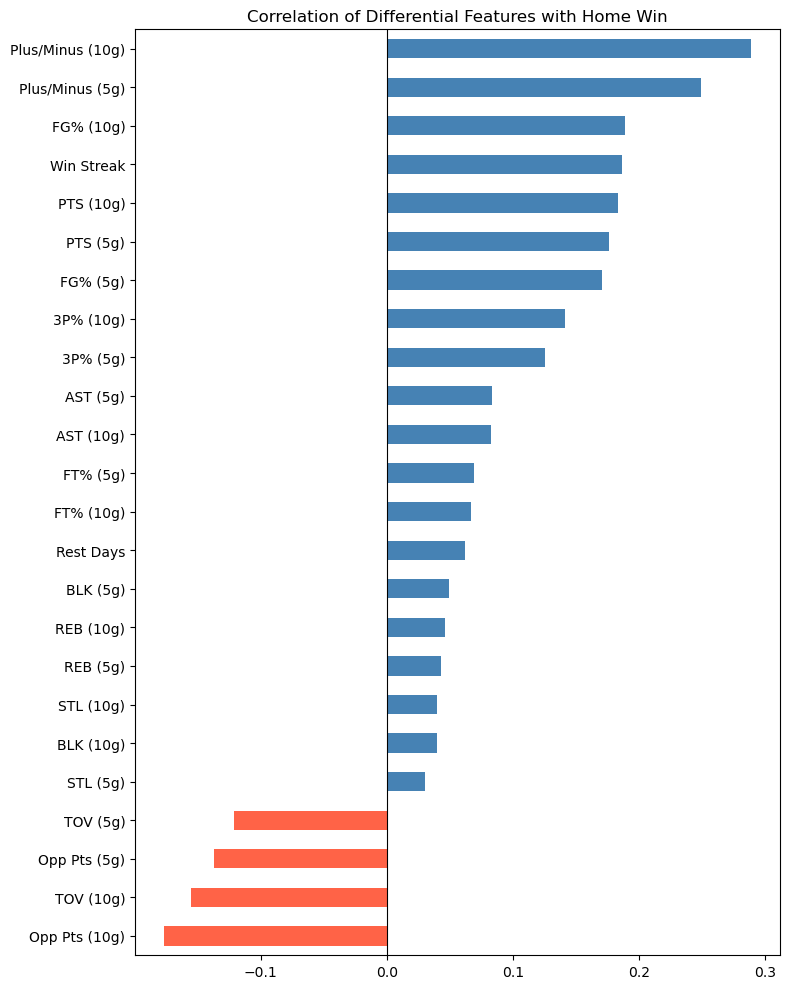

In [15]:
# Correlation of differential features with home win
clean = lambda s: s.replace('DIFF_','').replace('_ROLL5',' (5g)').replace('_ROLL10',' (10g)')\
    .replace('OPP_PTS','Opp Pts').replace('PLUS_MINUS','Plus/Minus')\
    .replace('REST_DAYS','Rest Days').replace('WIN_STREAK','Win Streak')\
    .replace('FG_PCT','FG%').replace('FG3_PCT','3P%').replace('FT_PCT','FT%').replace('_',' ')

diff_cols = [c for c in matchups.columns if c.startswith('DIFF_')]
corr = matchups[diff_cols+['home_win']].corr()['home_win'].drop('home_win').sort_values()
corr.index = [clean(i) for i in corr.index]

plt.figure(figsize=(8, 10))
corr.plot(kind='barh', color=['tomato' if v<0 else 'steelblue' for v in corr])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Differential Features with Home Win')
plt.tight_layout()
plt.savefig('../visuals/feature_correlations.png', dpi=150)
plt.show()